# VOR, VVOR, and OKN/OKAN — Replication of Raphan, Matsuo & Cohen (1979)

**Target figure:** Fig. 9 from Raphan, Matsuo & Cohen (1979) *Brain Research* 159:361–379.

This figure summarizes model predictions for three conditions, each shown as a schematic trace (left: slow-phase velocity only) and a signal breakdown (right: cupula + integrator + SPV).

| Panel | Condition | Key signals |
|-------|-----------|-------------|
| **A / B** | Step rotation in **darkness** | CUP decays fast (~τ_c); INT decays slowly (~τ_vs); SPV follows INT |
| **C / D** | Step of **surround velocity** (OKN + OKAN) | No CUP; INT charged by visual drive; SPV rises then decays (OKAN) |
| **E / F** | Rotation in **light** → stop in **dark** (VVOR) | CUP decays; INT maintained by OKR; SPV stays flat; post-rotatory follows INT |

The integrator (INT) is velocity storage (`x_vs`). The cupula (CUP) is the canal afferent head-velocity estimate (`PINV_SENS @ y_canal`).

---
> **Paper figure placeholder:** save scan as `paper_figures/raphan1979_fig9.png` and uncomment the cell below.

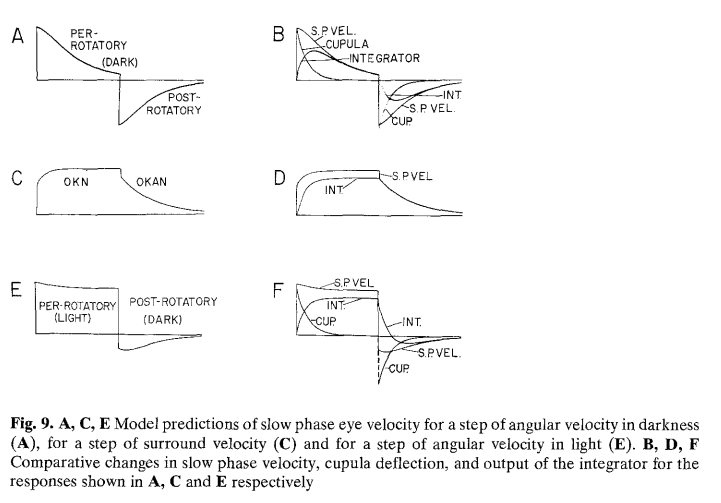

In [1]:
from IPython.display import Image
Image('images/raphan1979_fig9.png', width=700)

---
## Setup

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.special import softplus as sp_softplus
from scipy.optimize import curve_fit
from scipy.ndimage import binary_dilation

from oculomotor.sim.simulator import (
    PARAMS_DEFAULT, with_brain, simulate,
    _IDX_C, _IDX_VS, _IDX_VS_L, _IDX_VS_R, _IDX_NI, _IDX_VIS, _IDX_SG,
)
from oculomotor.models.sensory_models.sensory_model import (
    N_CANALS, FLOOR, _SOFTNESS, PINV_SENS, C_slip, C_pos, C_gate,
)
from oculomotor.models.brain_models import saccade_generator as sg_mod
from oculomotor.sim import stimuli as stim_mod
from oculomotor import __version__

print(f'oculomotor {__version__}')
THETA = PARAMS_DEFAULT
print(f'tau_c={THETA.sensory.tau_c} s  tau_vs={THETA.brain.tau_vs} s  '
      f'tau_i={THETA.brain.tau_i} s  tau_vis={THETA.sensory.tau_vis} s  '
      f'b_vs={THETA.brain.b_vs} deg/s')

%matplotlib widget
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 9

oculomotor 7fffc50-dirty
tau_c=5.0 s  tau_vs=20.0 s  tau_i=25.0 s  tau_vis=0.08 s  b_vs=100.0 deg/s


In [3]:
# ── Signal extraction helpers ──────────────────────────────────────────────────

def extract_canal(states):
    """Canal head-velocity estimate (yaw): PINV_SENS @ y_canal[:, 0].
    Positive = head rotating in +yaw direction.
    """
    x_c  = np.array(states.sensory[:, _IDX_C])
    x2   = x_c[:, N_CANALS:]
    k, f = float(_SOFTNESS), float(FLOOR)
    y_c  = -f + sp_softplus(k*(x2+f))/k + sp_softplus(k*(x2-f))/k
    pinv = np.array(PINV_SENS)
    return (pinv @ y_c.T).T[:, 0]


def extract_burst(states, theta):
    """Recompute u_burst (T, 3) via vmap. Returns yaw component (T,)."""
    def _at(state):
        x_vis_     = state.sensory[_IDX_VIS]
        e_pd       = C_pos  @ x_vis_
        gate_vf    = (C_gate @ x_vis_)[0]
        x_ni_      = state.brain[_IDX_NI]
        _, u_burst = sg_mod.step(state.brain[_IDX_SG], e_pd, gate_vf, x_ni_, theta.brain)
        return u_burst
    return np.array(jax.vmap(_at)(states))[:, 0]   # yaw only


def extract_spv(t, eye_vel, burst, burst_threshold=10.0, margin_s=0.05):
    """Slow-phase velocity using the saccade burst to detect fast phases.

    The burst signal is zero during slow phases regardless of SPV magnitude.
    A velocity threshold fails when SPV itself is large (e.g. late OKAN,
    high-gain OKN) — those slow phases get misclassified as fast phases.

    Parameters
    ----------
    burst           : (T,) yaw burst signal from extract_burst()
    burst_threshold : deg/s  — burst amplitude declaring a fast phase
    margin_s        : s      — window expansion around each fast phase
    """
    dt       = float(t[1] - t[0])
    margin_n = max(1, int(margin_s / dt))
    is_fast  = np.abs(burst) > burst_threshold
    is_fast  = binary_dilation(is_fast, structure=np.ones(2*margin_n + 1))
    slow     = ~is_fast
    if slow.sum() < 2:
        return eye_vel.copy()
    return np.interp(t, t[slow], eye_vel[slow])


def fit_tc(t, y, t_start, t_end, label=''):
    """Fit A*exp(-t/tau)+offset. Returns (tau, t_fit, y_fit) or (None, None, None)."""
    mask  = (t >= t_start) & (t <= t_end)
    t_seg = t[mask] - t_start
    y_seg = y[mask]
    try:
        p0   = (y_seg[0] - y_seg[-1], (t_end - t_start)/3, y_seg[-1])
        popt, _ = curve_fit(lambda t, A, tau, c: A*np.exp(-t/tau)+c,
                            t_seg, y_seg, p0=p0, maxfev=8000,
                            bounds=([-np.inf, 0.1, -np.inf], [np.inf, 200, np.inf]))
        tau   = abs(popt[1])
        y_fit = popt[0]*np.exp(-t_seg/tau) + popt[2]
        print(f'  {label}: τ = {tau:.1f} s')
        return tau, t[mask], y_fit
    except Exception as e:
        print(f'  {label}: fit failed — {e}')
        return None, None, None


def ax_fmt(ax, ylabel='', xlabel=''):
    ax.axhline(0, color='gray', lw=0.4)
    ax.grid(True, alpha=0.2)
    if ylabel: ax.set_ylabel(ylabel, fontsize=8)
    if xlabel: ax.set_xlabel(xlabel, fontsize=8)
    ax.tick_params(labelsize=7)

---
## Simulations

Three protocols matching Fig. 9 A/C/E:

- **A/B** — 60 deg/s step rotation for 30 s, then stop. **Darkness throughout.**
- **C/D** — Full-field surround at 30 deg/s for 30 s, then lights off. **No head motion.**
- **E/F** — 30 deg/s rotation for 30 s in **light** (stationary world), then stop and **lights off**.

In [4]:
SR = 200.0   # samples/s (shared across all conditions)
DT = 1.0 / SR

# ── A/B: VOR in dark ──────────────────────────────────────────────────────────
V_AB        = 60.0
ROT_AB      = 30.0
CST_AB      = 60.0
t_ab, hv_ab = stim_mod.rotation_step(V_AB, rotate_dur=ROT_AB, coast_dur=CST_AB, dt=DT)
T_ab        = len(t_ab)

print('A/B: VOR in dark...')
st_ab = simulate(THETA, t_ab,
                 head_vel_array        = hv_ab,
                 scene_present_array   = jnp.zeros(T_ab),
                 target_present_array  = jnp.zeros(T_ab),
                 max_steps = int((ROT_AB+CST_AB)/0.001)+500,
                 return_states=True)

# ── C/D: OKN + OKAN ───────────────────────────────────────────────────────────
V_CD        = 30.0
ON_CD       = 30.0
OFF_CD      = 50.0
t_cd        = jnp.arange(0.0, ON_CD + OFF_CD, DT)
T_cd        = len(t_cd)
v_sc        = jnp.zeros((T_cd, 3)).at[:, 0].set(jnp.where(t_cd < ON_CD, V_CD, 0.0))
sc_pres_cd  = jnp.where(t_cd < ON_CD, 1.0, 0.0)   # lights off when scene stops

print('C/D: OKN + OKAN...')
st_cd = simulate(THETA, t_cd,
                 v_scene_array         = v_sc,
                 scene_present_array   = sc_pres_cd,
                 target_present_array  = jnp.zeros(T_cd),  # pure OKN, no foveal target
                 max_steps = int((ON_CD+OFF_CD)/0.001)+500,
                 return_states=True)

# ── E/F: VVOR — rotate in light, stop in dark ─────────────────────────────────
V_EF        = 30.0
ROT_EF      = 30.0
CST_EF      = 50.0
t_ef, hv_ef = stim_mod.rotation_step(V_EF, rotate_dur=ROT_EF, coast_dur=CST_EF, dt=DT)
T_ef        = len(t_ef)
sc_pres_ef  = jnp.where(t_ef < ROT_EF, 1.0, 0.0)  # scene on during rotation only
tgt_pres_ef = jnp.where(t_ef < ROT_EF, 1.0, 0.0)  # target also disappears when lights go off

print('E/F: VVOR (light → dark)...')
st_ef = simulate(THETA, t_ef,
                 head_vel_array        = hv_ef,
                 scene_present_array   = sc_pres_ef,
                 target_present_array  = tgt_pres_ef,
                 max_steps = int((ROT_EF+CST_EF)/0.001)+500,
                 return_states=True)

print('Done.')

A/B: VOR in dark...
C/D: OKN + OKAN...
E/F: VVOR (light → dark)...
Done.


In [5]:
# ── Compute bursts first — used for fast phase detection in extract_spv ───────
print('Computing burst signals (vmap over trajectories)...')
burst_ab = extract_burst(st_ab, THETA)
burst_cd = extract_burst(st_cd, THETA)
burst_ef = extract_burst(st_ef, THETA)
print('Done.')

# ── Extract signals ────────────────────────────────────────────────────────────
# Sign convention:
#   CUP  = canal yaw estimate  (+ = head rotating right)
#   INT  = VS net signal = x_L - x_R  (+ = rightward head velocity stored)
#   SPV  = slow-phase vel      (+ = eye moving in compensatory direction)
#          → VOR/VVOR: SPV = -eye_vel  (compensatory eye is opposite to head)
#          → OKN:      SPV = +eye_vel  (eye tracks scene in same direction)
#
# INT sign notes:
#   VOR (A/B):  x_L-x_R > 0  (rightward head → left pop up, right pop down) → display as-is
#   OKN (C/D):  x_L-x_R < 0  (rightward slip → right pop up, left pop down) → negate for display
#   VVOR (E/F): x_L-x_R > 0  (same as VOR) → display as-is

def vs_net(states):
    """Net VS signal (x_L - x_R) yaw component."""
    return (np.array(states.brain[:, _IDX_VS_L]) - np.array(states.brain[:, _IDX_VS_R]))[:, 0]

t_ab_np = np.array(t_ab)
t_cd_np = np.array(t_cd)
t_ef_np = np.array(t_ef)

# A/B — VOR in dark
ep_ab       = np.array(st_ab.plant)[:, 0]
ev_ab       = np.gradient(ep_ab, DT)
spv_ab      = extract_spv(t_ab_np, ev_ab, burst_ab)
cup_ab      = extract_canal(st_ab)
int_ab_disp = vs_net(st_ab)          # x_L-x_R > 0 during rightward VOR → display as-is
spv_ab_disp = -spv_ab                # compensatory leftward eye → display positive

# C/D — OKN + OKAN
ep_cd       = np.array(st_cd.plant)[:, 0]
ev_cd       = np.gradient(ep_cd, DT)
spv_cd      = extract_spv(t_cd_np, ev_cd, burst_cd)
cup_cd      = np.zeros_like(t_cd_np)   # no head motion
int_cd_disp = -vs_net(st_cd)          # x_L-x_R < 0 during rightward OKN → negate for display
spv_cd_disp = spv_cd                  # eye tracks rightward scene → display positive

# E/F — VVOR
ep_ef       = np.array(st_ef.plant)[:, 0]
ev_ef       = np.gradient(ep_ef, DT)
spv_ef      = extract_spv(t_ef_np, ev_ef, burst_ef)
cup_ef      = extract_canal(st_ef)
int_ef_disp = vs_net(st_ef)           # x_L-x_R > 0 during rightward VVOR → display as-is
spv_ef_disp = -spv_ef

print(f'Fast phases detected:  '
      f'A/B {(np.abs(burst_ab)>10).mean()*100:.1f}%  '
      f'C/D {(np.abs(burst_cd)>10).mean()*100:.1f}%  '
      f'E/F {(np.abs(burst_ef)>10).mean()*100:.1f}%')

Computing burst signals (vmap over trajectories)...
Done.
Fast phases detected:  A/B 15.8%  C/D 14.6%  E/F 94.1%


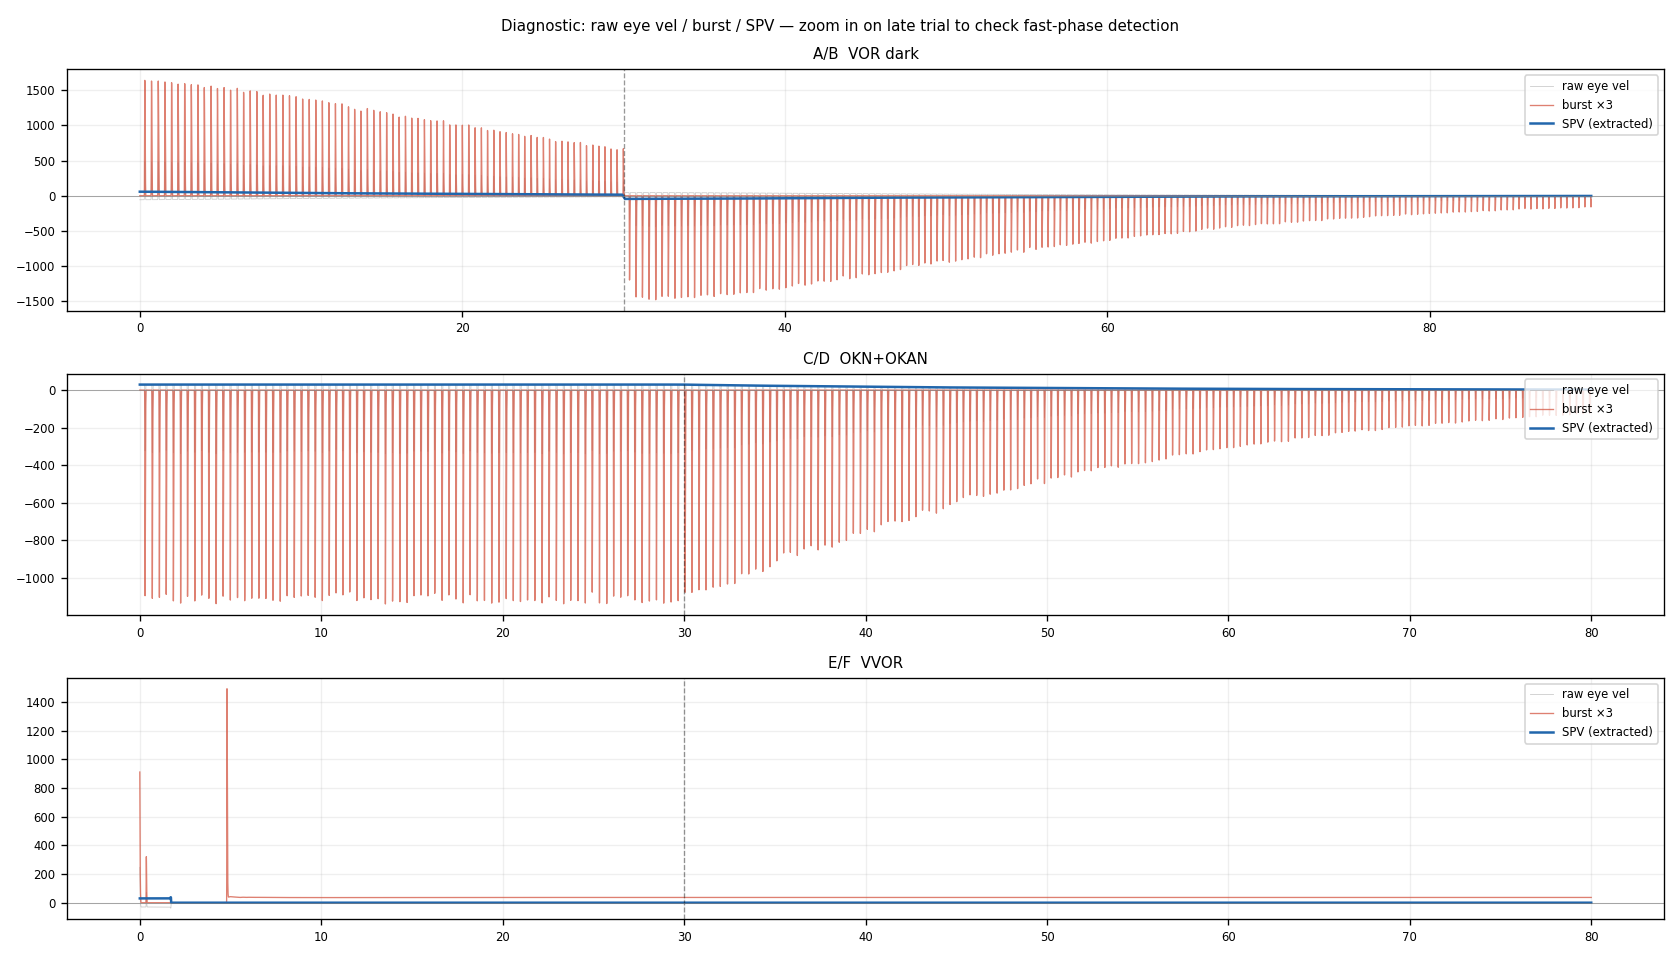

In [6]:
# ── Diagnostic: raw eye vel vs burst vs SPV for each condition ─────────────────
# Use this to tune burst_threshold and spot SG misfires late in the trial.

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)

for i, (label, t_np, ev, burst, spv_disp, t_event) in enumerate([
    ('A/B  VOR dark',    t_ab_np, ev_ab,  burst_ab, spv_ab_disp, ROT_AB),
    ('C/D  OKN+OKAN',   t_cd_np, ev_cd,  burst_cd, spv_cd_disp, ON_CD),
    ('E/F  VVOR',        t_ef_np, ev_ef,  burst_ef, spv_ef_disp, ROT_EF),
]):
    ax = axes[i]
    ax.plot(t_np, ev,       color='#aaaaaa', lw=0.5, alpha=0.6, label='raw eye vel')
    ax.plot(t_np, burst*3,  color='#d6604d', lw=0.8, alpha=0.8, label='burst ×3')
    ax.plot(t_np, spv_disp, color='#2166ac', lw=1.5, label='SPV (extracted)')
    ax.axvline(t_event, color='k', lw=0.8, ls='--', alpha=0.4)
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=7)

fig.suptitle('Diagnostic: raw eye vel / burst / SPV — zoom in on late trial to check fast-phase detection',
             fontsize=9)
fig.tight_layout()
plt.show()

---
## Fig. 9 — Replication (panels A–F)

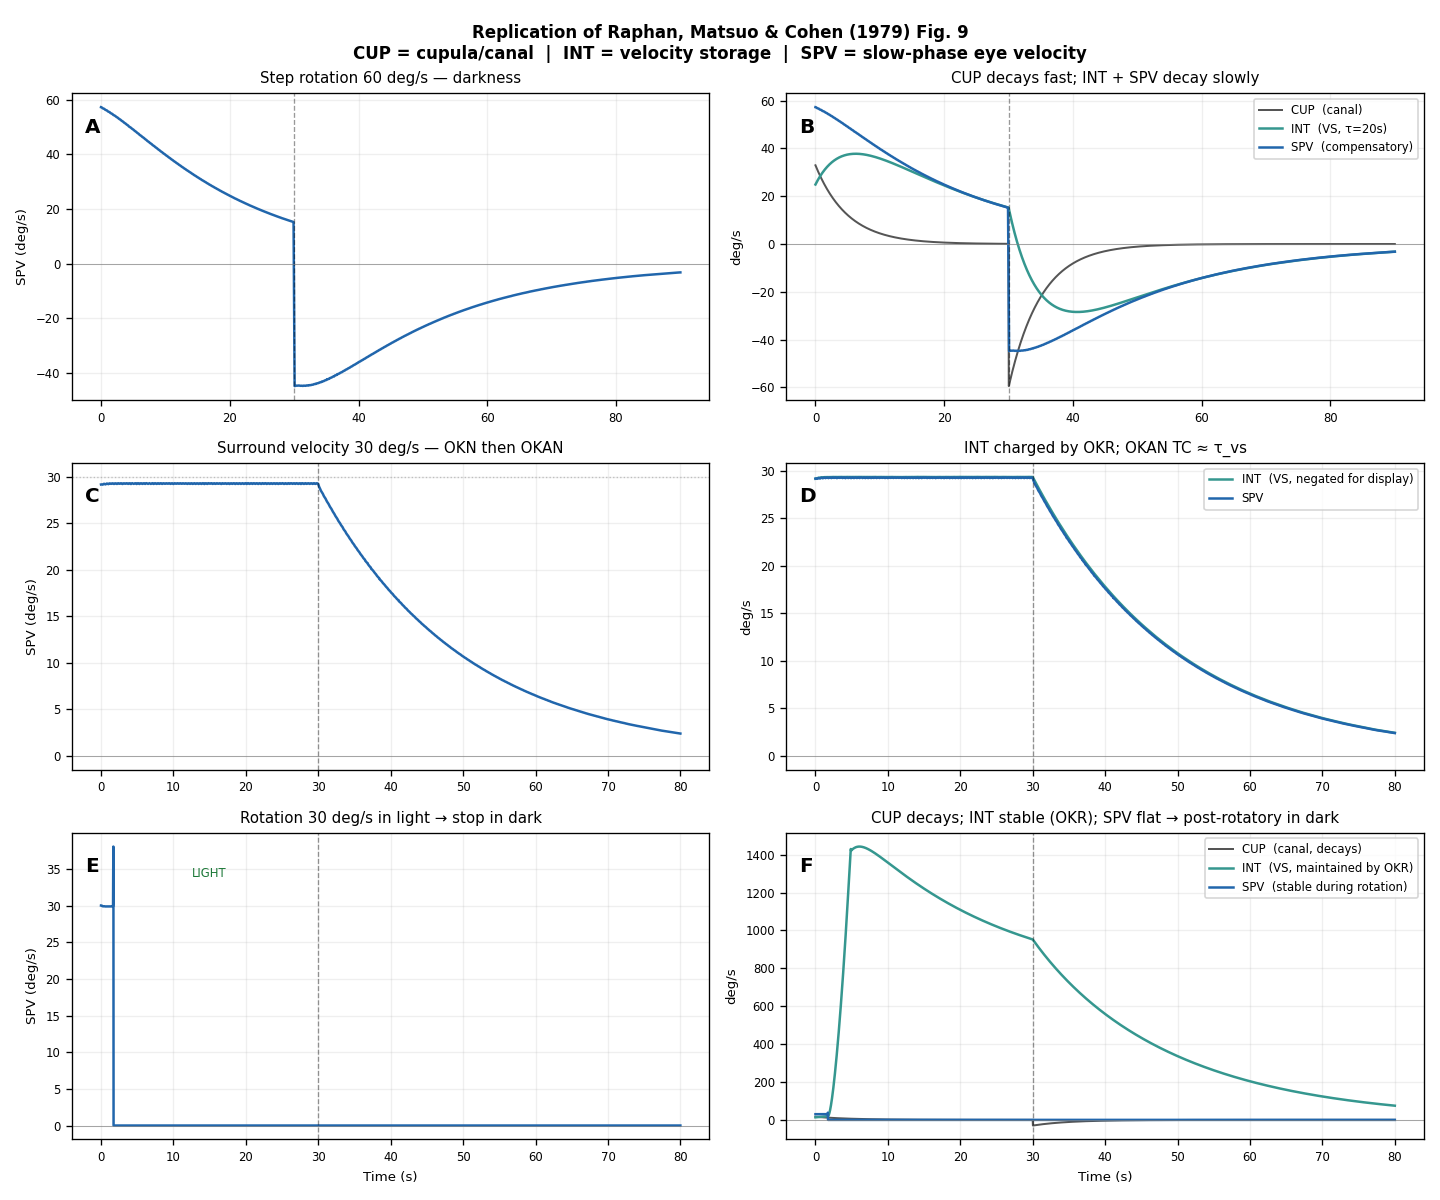

In [7]:
C_cup = '#555555'    # cupula
C_int = '#35978f'    # integrator / VS
C_spv = '#2166ac'    # slow-phase velocity
C_ref = '#aaaaaa'    # reference lines

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle(
    'Replication of Raphan, Matsuo & Cohen (1979) Fig. 9\n'
    'CUP = cupula/canal  |  INT = velocity storage  |  SPV = slow-phase eye velocity',
    fontsize=10, fontweight='bold')

panel_labels = [['A', 'B'], ['C', 'D'], ['E', 'F']]

def label_panel(ax, letter, x=0.02, y=0.92):
    ax.text(x, y, letter, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top')

# ── A: VOR dark — SPV only ─────────e───────────────────────────────────────────
ax = axes[0, 0]
ax.plot(t_ab_np, spv_ab_disp, color=C_spv, lw=1.5)
ax.axvline(ROT_AB, color='k', lw=0.8, ls='--', alpha=0.4)
ax_fmt(ax, ylabel='SPV (deg/s)')
ax.set_title(f'Step rotation {V_AB:.0f} deg/s — darkness', fontsize=9)
label_panel(ax, 'A')

# ── B: VOR dark — CUP + INT + SPV ────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(t_ab_np, cup_ab,       color=C_cup, lw=1.2, label='CUP  (canal)')
ax.plot(t_ab_np, int_ab_disp,  color=C_int, lw=1.5, label=f'INT  (VS, τ={THETA.brain.tau_vs:.0f}s)')
ax.plot(t_ab_np, spv_ab_disp,  color=C_spv, lw=1.5, label='SPV  (compensatory)')
ax.axvline(ROT_AB, color='k', lw=0.8, ls='--', alpha=0.4)
ax_fmt(ax, ylabel='deg/s')
ax.legend(fontsize=7, loc='upper right')
ax.set_title('CUP decays fast; INT + SPV decay slowly', fontsize=9)
label_panel(ax, 'B')

# ── C: OKN + OKAN — SPV only ─────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(t_cd_np, spv_cd_disp, color=C_spv, lw=1.5)
ax.axvline(ON_CD, color='k', lw=0.8, ls='--', alpha=0.4)
ax.axhline(V_CD, color=C_ref, lw=0.8, ls=':', alpha=0.7)
ax_fmt(ax, ylabel='SPV (deg/s)')
ax.set_title(f'Surround velocity {V_CD:.0f} deg/s — OKN then OKAN', fontsize=9)
label_panel(ax, 'C')

# ── D: OKN + OKAN — INT + SPV ─────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(t_cd_np, int_cd_disp,  color=C_int, lw=1.5, label='INT  (VS, negated for display)')
ax.plot(t_cd_np, spv_cd_disp,  color=C_spv, lw=1.5, label='SPV')
ax.axvline(ON_CD, color='k', lw=0.8, ls='--', alpha=0.4)
ax_fmt(ax, ylabel='deg/s')
ax.legend(fontsize=7, loc='upper right')
ax.set_title('INT charged by OKR; OKAN TC ≈ τ_vs', fontsize=9)
label_panel(ax, 'D')

# ── E: VVOR — SPV only ────────────────────────────────────────────────────────
ax = axes[2, 0]
ax.plot(t_ef_np, spv_ef_disp, color=C_spv, lw=1.5)
ax.axvline(ROT_EF, color='k', lw=0.8, ls='--', alpha=0.4)
ax.text(ROT_EF/2, ax.get_ylim()[1]*0.85 if ax.get_ylim()[1] > 0 else 2,
        'LIGHT', ha='center', fontsize=7, color='#1b7837')
ax_fmt(ax, ylabel='SPV (deg/s)', xlabel='Time (s)')
ax.set_title(f'Rotation {V_EF:.0f} deg/s in light → stop in dark', fontsize=9)
label_panel(ax, 'E')

# ── F: VVOR — CUP + INT + SPV ────────────────────────────────────────────────
ax = axes[2, 1]
ax.plot(t_ef_np, cup_ef,       color=C_cup, lw=1.2, label='CUP  (canal, decays)')
ax.plot(t_ef_np, int_ef_disp,  color=C_int, lw=1.5, label='INT  (VS, maintained by OKR)')
ax.plot(t_ef_np, spv_ef_disp,  color=C_spv, lw=1.5, label='SPV  (stable during rotation)')
ax.axvline(ROT_EF, color='k', lw=0.8, ls='--', alpha=0.4)
ax_fmt(ax, ylabel='deg/s', xlabel='Time (s)')
ax.legend(fontsize=7, loc='upper right')
ax.set_title('CUP decays; INT stable (OKR); SPV flat → post-rotatory in dark', fontsize=9)
label_panel(ax, 'F')

fig.tight_layout()
plt.show()

---
## Time constant fits

Fitting exponential decays to SPV to extract the key time constants.

In [8]:
print('=== A/B: VOR in dark ===')
# Canal TC: fit cup_ab during rotation onset (rise then decay)
tau_cup, *_ = fit_tc(t_ab_np, cup_ab, t_start=1.0, t_end=ROT_AB-5.0, label='CUP decay (canal TC)')

# Post-rotatory VOR TC: fit SPV after rotation stops
tau_vor, t_fit, y_fit = fit_tc(
    t_ab_np, spv_ab_disp, t_start=ROT_AB+1.0, t_end=ROT_AB+45.0, label='SPV post-rotatory TC')

print(f'\n=== C/D: OKN + OKAN ===')
# OKAN TC: fit SPV after lights off
tau_okan, t_fit_okan, y_fit_okan = fit_tc(
    t_cd_np, spv_cd_disp, t_start=ON_CD+2.0, t_end=ON_CD+40.0, label='OKAN TC')

print(f'\n=== E/F: VVOR ===')
# Post-rotatory TC after stop in dark
tau_vvor, t_fit_vvor, y_fit_vvor = fit_tc(
    t_ef_np, spv_ef_disp, t_start=ROT_EF+1.0, t_end=ROT_EF+40.0, label='SPV post-rotatory TC (VVOR)')

print(f'\n=== Summary ===')
print(f'  tau_c  (model)  = {THETA.sensory.tau_c:.1f} s')
print(f'  tau_vs (model)  = {THETA.brain.tau_vs:.1f} s')
print(f'  CUP decay       = {tau_cup:.1f} s  (expect ≈ tau_c)' if tau_cup else '')
print(f'  VOR post-rot TC = {tau_vor:.1f} s  (expect ≈ tau_vs)' if tau_vor else '')
print(f'  OKAN TC         = {tau_okan:.1f} s  (expect ≈ tau_vs)' if tau_okan else '')
print(f'  VVOR post-rot   = {tau_vvor:.1f} s  (expect ≈ tau_vs)' if tau_vvor else '')

=== A/B: VOR in dark ===
  CUP decay (canal TC): τ = 5.0 s
  SPV post-rotatory TC: τ = 35.7 s

=== C/D: OKN + OKAN ===
  OKAN TC: τ = 20.0 s

=== E/F: VVOR ===
  SPV post-rotatory TC (VVOR): τ = 13.0 s

=== Summary ===
  tau_c  (model)  = 5.0 s
  tau_vs (model)  = 20.0 s
  CUP decay       = 5.0 s  (expect ≈ tau_c)
  VOR post-rot TC = 35.7 s  (expect ≈ tau_vs)
  OKAN TC         = 20.0 s  (expect ≈ tau_vs)
  VVOR post-rot   = 13.0 s  (expect ≈ tau_vs)


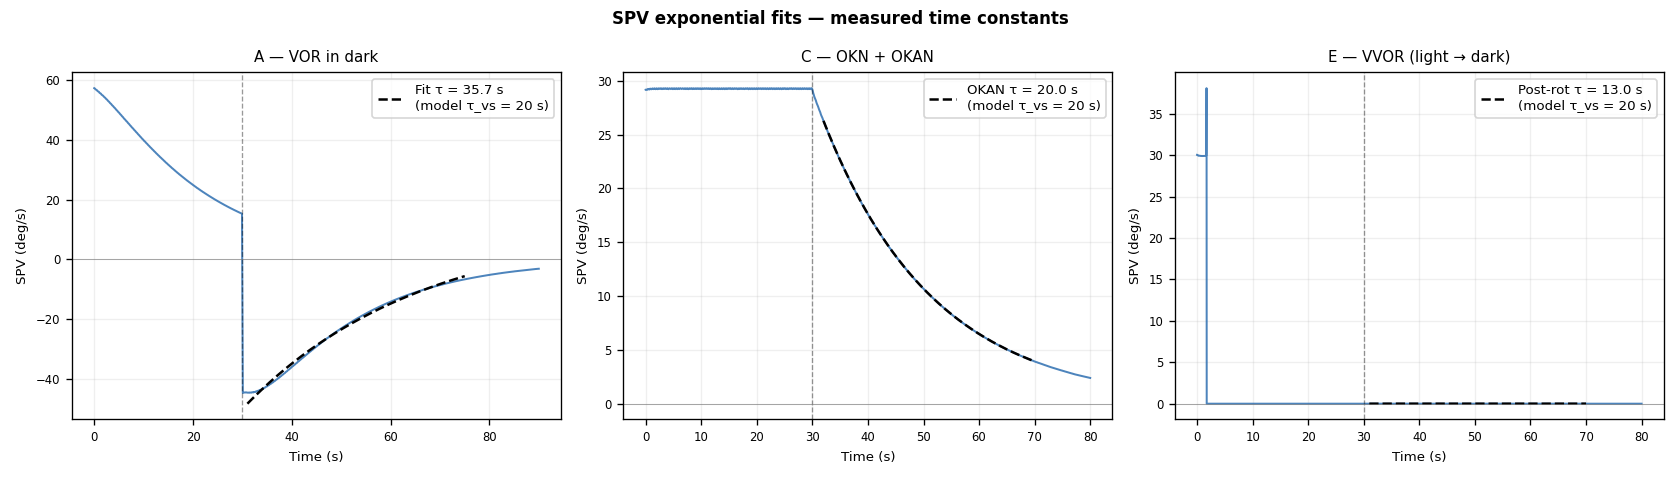

In [9]:
# ── Plot SPV fits with exponential overlays ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

# A/B fit
ax = axes[0]
ax.plot(t_ab_np, spv_ab_disp, color=C_spv, lw=1.2, alpha=0.8)
if t_fit is not None:
    ax.plot(t_fit, y_fit, 'k--', lw=1.5,
            label=f'Fit τ = {tau_vor:.1f} s\n(model τ_vs = {THETA.brain.tau_vs:.0f} s)')
ax.axvline(ROT_AB, color='k', lw=0.8, ls='--', alpha=0.4)
ax_fmt(ax, ylabel='SPV (deg/s)', xlabel='Time (s)')
ax.set_title('A — VOR in dark', fontsize=9)
if t_fit is not None: ax.legend(fontsize=8)

# C/D fit
ax = axes[1]
ax.plot(t_cd_np, spv_cd_disp, color=C_spv, lw=1.2, alpha=0.8)
if t_fit_okan is not None:
    ax.plot(t_fit_okan, y_fit_okan, 'k--', lw=1.5,
            label=f'OKAN τ = {tau_okan:.1f} s\n(model τ_vs = {THETA.brain.tau_vs:.0f} s)')
ax.axvline(ON_CD, color='k', lw=0.8, ls='--', alpha=0.4)
ax_fmt(ax, ylabel='SPV (deg/s)', xlabel='Time (s)')
ax.set_title('C — OKN + OKAN', fontsize=9)
if t_fit_okan is not None: ax.legend(fontsize=8)

# E/F fit
ax = axes[2]
ax.plot(t_ef_np, spv_ef_disp, color=C_spv, lw=1.2, alpha=0.8)
if t_fit_vvor is not None:
    ax.plot(t_fit_vvor, y_fit_vvor, 'k--', lw=1.5,
            label=f'Post-rot τ = {tau_vvor:.1f} s\n(model τ_vs = {THETA.brain.tau_vs:.0f} s)')
ax.axvline(ROT_EF, color='k', lw=0.8, ls='--', alpha=0.4)
ax_fmt(ax, ylabel='SPV (deg/s)', xlabel='Time (s)')
ax.set_title('E — VVOR (light → dark)', fontsize=9)
if t_fit_vvor is not None: ax.legend(fontsize=8)

fig.suptitle('SPV exponential fits — measured time constants', fontsize=10, fontweight='bold')
fig.tight_layout()
plt.show()

---
## Comparison table

| Quantity | Raphan et al. 1979 (monkey) | Model (fit above) |
|----------|-----------------------------|-----------------|
| Canal TC (CUP) | ~5 s | |
| Post-rotatory VOR TC (dark) | ~15–20 s | |
| OKAN TC | ~15–20 s | |
| VVOR post-rotatory TC | ~15–20 s | |
| OKN plateau gain | ~0.8–1.0 | |
| VVOR stabilization (gaze error near 0?) | Yes | |

---
## Parameter sensitivity

| Parameter | Primary effect |
|-----------|---------------|
| `tau_vs` ↑ | Longer post-rotatory VOR TC; longer OKAN TC |
| `K_vs` ↑ | VS charges faster → higher post-rotatory amplitude |
| `tau_c` ↑ | Canal adapts more slowly → per-rotatory SPV decays more slowly |
| `K_vis` ↑ | Stronger OKR → higher OKN gain; better VVOR stabilization |
| `g_vis` ↑ | Direct OKR feedforward gain → faster OKN rise |
| `tau_vis` ↑ | Longer visual delay → lower OKN gain at high scene velocities |

---
## Sinusoidal VOR at 2 Hz

Three conditions during sinusoidal head rotation at 2 Hz, ±20 deg/s peak:

| Condition | Scene | Target | Active pathways |
|-----------|-------|--------|-----------------|
| **Dark** | off | off | Canal → VS → NI → plant only |
| **Scene, no target** | on (stationary world) | off | + OKR corrects slip |
| **Scene + fixation target** | on | on (0°, world-fixed) | + OKR + pursuit fixation |

Protocol: 2 s stationary → 6 s oscillation → 3 s stationary.
Gain and phase estimated over the steady-state window (t = 3–7 s) using the Hilbert transform.

In [10]:
%%time
from scipy.signal import butter, filtfilt, hilbert as sp_hilbert

F_SIN   = 2.0    # Hz
V_PEAK  = 20.0   # deg/s peak head velocity
T_PRE   = 2.0    # s stationary before oscillation
T_OSC   = 6.0    # s oscillation
T_POST  = 3.0    # s stationary after
T_TOTAL = T_PRE + T_OSC + T_POST

SR_VOR = 200.0
DT_VOR = 1.0 / SR_VOR

t_sv    = jnp.arange(0.0, T_TOTAL, DT_VOR)
T_sv    = len(t_sv)
t_sv_np = np.array(t_sv)

active = (t_sv_np >= T_PRE) & (t_sv_np < T_PRE + T_OSC)
hv_np  = np.where(active, V_PEAK * np.sin(2 * np.pi * F_SIN * (t_sv_np - T_PRE)), 0.0).astype(np.float32)
hv3_sv = jnp.stack([jnp.array(hv_np), jnp.zeros(T_sv), jnp.zeros(T_sv)], axis=1)

CONDITIONS_SV = [
    ('Dark',                    dict(scene_present_array=jnp.zeros(T_sv),
                                     target_present_array=jnp.zeros(T_sv))),
    ('Scene, no target',        dict(scene_present_array=jnp.ones(T_sv),
                                     target_present_array=jnp.zeros(T_sv))),
    ('Scene + fixation target', dict(scene_present_array=jnp.ones(T_sv),
                                     target_present_array=jnp.ones(T_sv))),
]

sv_data = {}
for name, kw in CONDITIONS_SV:
    print(f'  {name}...')
    st = simulate(THETA, t_sv, head_vel_array=hv3_sv,
                  max_steps=int(T_TOTAL / 0.001) + 500,
                  return_states=True, **kw)
    burst = extract_burst(st, THETA)
    ev    = np.gradient(np.array(st.plant[:, 0]), DT_VOR)
    spv   = extract_spv(t_sv_np, ev, burst)
    sv_data[name] = dict(ev=ev, spv=spv, burst=burst)
    del st
print('Done.')

  Dark...


  Scene, no target...
  Scene + fixation target...
Done.
CPU times: total: 34.4 s
Wall time: 20.1 s


=== Sinusoidal VOR at 2 Hz — gain & phase ===
  Dark                          gain = 0.904   phase = -3.5°
  Scene, no target              gain = 0.917   phase = -2.9°
  Scene + fixation target       gain = 1.047   phase = -1.1°


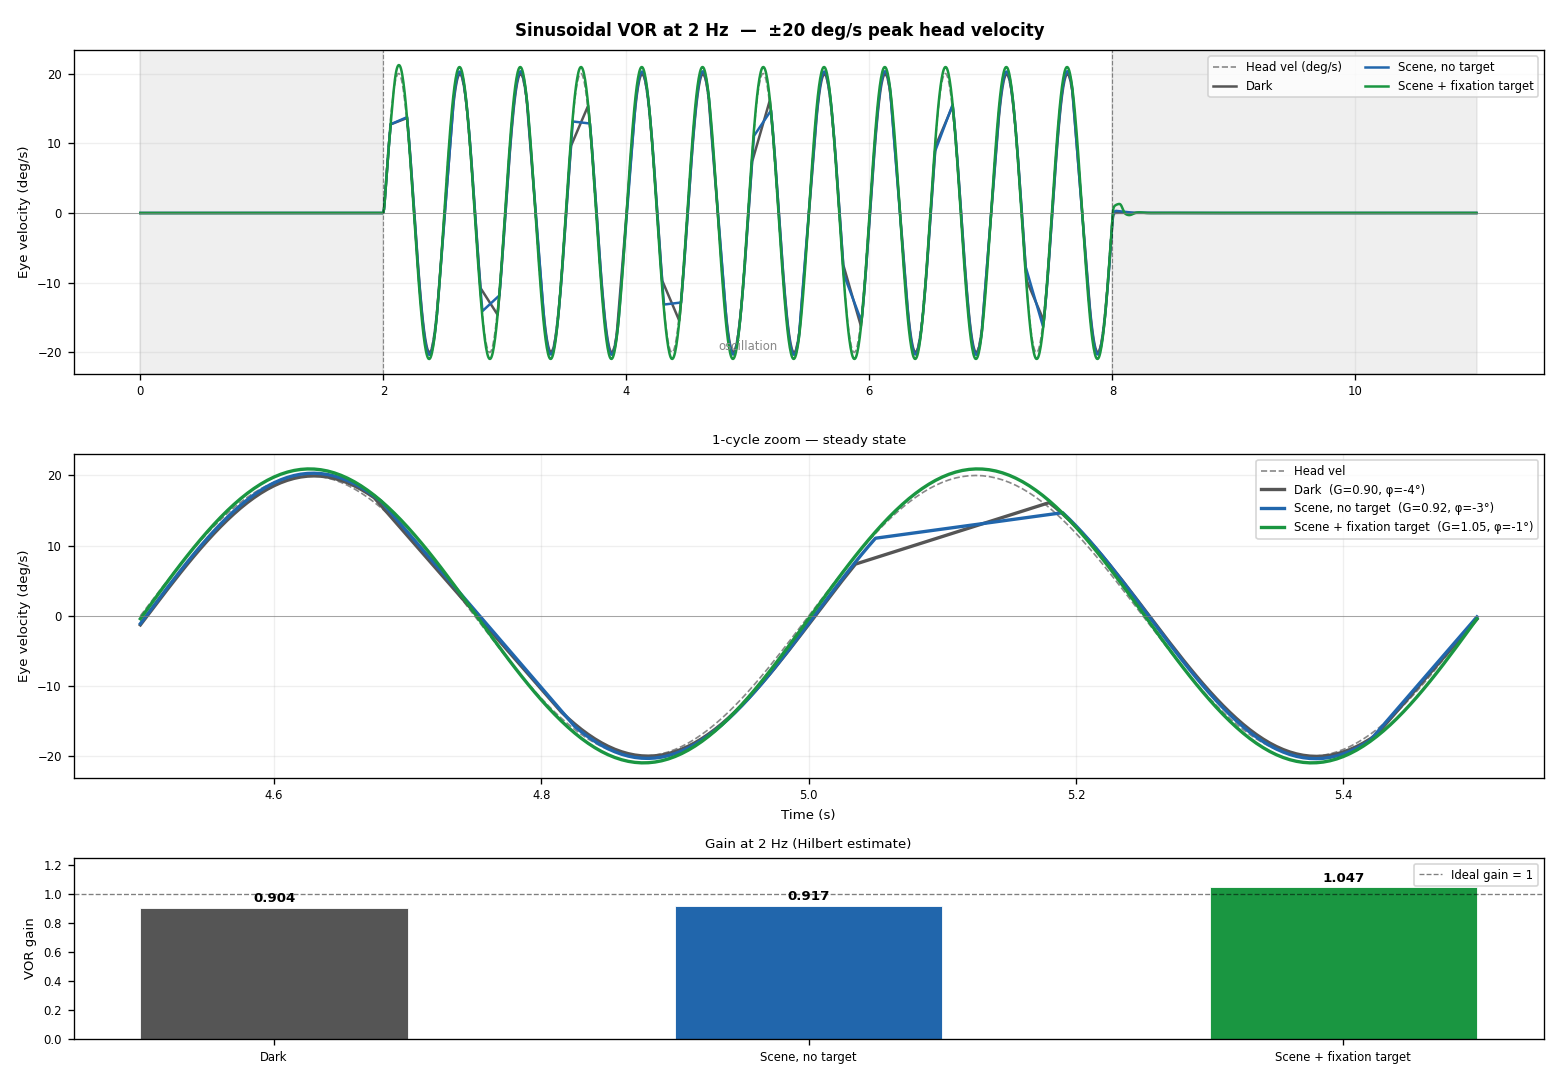

In [11]:
def hilbert_gain_phase(t, spv, hv, t0, t1, f):
    """Measure VOR gain and phase at frequency f using Hilbert transform."""
    mask = (t >= t0) & (t <= t1)
    SR   = 1.0 / (t[1] - t[0])
    lo   = max(f * 0.5, 0.5)
    hi   = min(f * 2.0, SR / 2.0 - 1.0)
    b, a = butter(4, [lo, hi], btype='band', fs=SR)
    # VOR SPV is -eye_vel (compensatory); negate so it aligns with head vel for gain
    spv_f = filtfilt(b, a,  spv[mask])
    hv_f  = filtfilt(b, a, -hv[mask])          # -hv so gain=1 means perfect compensation
    a_spv = np.abs(sp_hilbert(spv_f))
    a_hv  = np.abs(sp_hilbert(hv_f))
    gain  = float(np.mean(a_spv) / np.mean(a_hv))
    phi   = np.angle(sp_hilbert(spv_f)) - np.angle(sp_hilbert(hv_f))
    phase = float(np.degrees(np.angle(np.mean(np.exp(1j * phi)))))
    return gain, phase


# Steady-state window (avoid onset/offset transients)
t_g0, t_g1 = T_PRE + 1.5, T_PRE + T_OSC - 0.5

COLORS_SV = {
    'Dark':                    '#555555',
    'Scene, no target':        '#2166ac',
    'Scene + fixation target': '#1a9641',
}

gains, phases = {}, {}
print('=== Sinusoidal VOR at 2 Hz — gain & phase ===')
for name, d in sv_data.items():
    g, p = hilbert_gain_phase(t_sv_np, d['spv'], hv_np, t_g0, t_g1, F_SIN)
    gains[name], phases[name] = g, p
    print(f'  {name:28s}  gain = {g:.3f}   phase = {p:+.1f}°')

# ── Figure: 3 panels ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 9),
                          gridspec_kw={'height_ratios': [2.5, 2.5, 1.4]})
fig.suptitle(
    f'Sinusoidal VOR at {F_SIN:.0f} Hz  —  ±{V_PEAK:.0f} deg/s peak head velocity',
    fontsize=10, fontweight='bold')

# ── Panel 1: full time course (SPV and head velocity) ────────────────────────
ax = axes[0]
ax.plot(t_sv_np, hv_np, color='#888888', lw=1.0, ls='--', label='Head vel (deg/s)', zorder=1)
for name, d in sv_data.items():
    ax.plot(t_sv_np, -d['spv'], color=COLORS_SV[name], lw=1.5, label=name)
ax.axvspan(0, T_PRE, color='#333333', alpha=0.08)
ax.axvspan(T_PRE + T_OSC, T_TOTAL, color='#333333', alpha=0.08)
ax.axvline(T_PRE,           color='k', lw=0.7, ls='--', alpha=0.4)
ax.axvline(T_PRE + T_OSC,   color='k', lw=0.7, ls='--', alpha=0.4)
ax.axhline(0, color='gray', lw=0.4)
ax.set_ylabel('Eye velocity (deg/s)', fontsize=8)
ax.legend(fontsize=7, loc='upper right', ncol=2)
ax.grid(True, alpha=0.2)
ax.tick_params(labelsize=7)
ax.text(T_PRE + T_OSC/2, ax.get_ylim()[0] * 0.85 if ax.get_ylim()[0] < 0 else -V_PEAK * 0.8,
        'oscillation', ha='center', fontsize=7, color='#888888')

# ── Panel 2: 1-cycle zoom in the middle of the oscillation ───────────────────
ax   = axes[1]
t_zm = T_PRE + T_OSC / 2.0        # centre of oscillation
t_z0 = t_zm - 1.0 / F_SIN
t_z1 = t_zm + 1.0 / F_SIN
msk  = (t_sv_np >= t_z0) & (t_sv_np <= t_z1)
ax.plot(t_sv_np[msk], hv_np[msk], color='#888888', lw=1.0, ls='--', label='Head vel')
for name, d in sv_data.items():
    ax.plot(t_sv_np[msk], -d['spv'][msk], color=COLORS_SV[name], lw=2.0,
            label=f'{name}  (G={gains[name]:.2f}, φ={phases[name]:+.0f}°)')
ax.axhline(0, color='gray', lw=0.4)
ax.set_ylabel('Eye velocity (deg/s)', fontsize=8)
ax.set_xlabel('Time (s)', fontsize=8)
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.2)
ax.tick_params(labelsize=7)
ax.set_title('1-cycle zoom — steady state', fontsize=8)

# ── Panel 3: gain bar chart ───────────────────────────────────────────────────
ax     = axes[2]
names  = list(gains.keys())
g_vals = [gains[n] for n in names]
colors = [COLORS_SV[n] for n in names]
bars   = ax.bar(names, g_vals, color=colors, width=0.5, edgecolor='white', linewidth=0.5)
ax.axhline(1.0, color='k', lw=0.8, ls='--', alpha=0.5, label='Ideal gain = 1')
ax.set_ylim(0, 1.25)
ax.set_ylabel('VOR gain', fontsize=8)
ax.set_title('Gain at 2 Hz (Hilbert estimate)', fontsize=8)
ax.legend(fontsize=7)
ax.tick_params(labelsize=7)
for bar, g in zip(bars, g_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, g + 0.02,
            f'{g:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

fig.tight_layout()
plt.show()